# CV-RLD graphs for different combinations of soil core numbers and layer thicknesses

### Imports and helper functions

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import LogLocator, ScalarFormatter
from scipy.stats import lognorm
from pathlib import Path

BASE_DIR = Path.cwd()

In [3]:
# transform to perirhizal radius PDF (analytically)
def pdf_perirhizal_mm(r_mm: np.ndarray, mu_ln: float, sigma_ln: float) -> np.ndarray:
    """Closed-form PDF for radius in mm induced by a lognormal RLD.

    Assumptions:
        - X = RLD is lognormal with ln(X) ~ N(mu_ln, sigma_ln^2)
        - Radius mapping: r_mm = 10 * sqrt(1 / (pi * X))

    Then r_mm is also lognormal with
        ln(r_mm) ~ N(mu_r, sigma_r^2)
        mu_r    = ln(10) - 0.5*ln(pi) - 0.5*mu_ln
        sigma_r = 0.5*sigma_ln
    """
    mu_r = np.log(10.0) - 0.5 * np.log(np.pi) - 0.5 * mu_ln
    sigma_r = 0.5 * sigma_ln
    return lognorm.pdf(r_mm, s=sigma_r, scale=np.exp(mu_r))

In [4]:
SD_BAND_MULTIPLIER = 1.0  # 1.0 means fitted CV +/- 1 residual standard deviation

def fit_log10_regression_with_sd_band(x, y, sd_multiplier=SD_BAND_MULTIPLIER):
    """Fit CV = a * log10(RLD) + b and store residual SD for the shaded band."""
    # Convert inputs to numpy arrays so filtering/math works consistently.
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Keep only usable points. RLD must be positive because log10(0) is undefined.
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0)
    x = x[mask]
    y = y[mask]

    if x.size < 3:
        raise ValueError("Need at least 3 valid points to fit the regression and residual SD band.")

    # Fit a straight line against log10(RLD), not raw RLD.
    x_log = np.log10(x)
    coef, cov = np.polyfit(x_log, y, 1, cov=True)
    a, b = coef

    # Residuals describe how far the observed CV points are from the fitted line.
    y_fit = a * x_log + b
    residuals = y - y_fit

    # Residual SD is the typical vertical scatter around the line.
    # The shaded band later uses: fitted CV +/- sd_multiplier * residual_sd.
    dof = x.size - 2
    sse = np.sum(residuals ** 2)
    mse = sse / dof
    residual_sd = np.sqrt(mse)

    # Store everything needed for plotting/prediction later.
    return {
        "a": a,
        "b": b,
        "cov": cov,  # kept for printing/checking; not used for the SD band
        "sd_multiplier": sd_multiplier,
        "n": x.size,
        "dof": dof,
        "mse": mse,
        "residual_sd": residual_sd,
        "x_min": x.min(),
        "x_max": x.max(),
    }

def predict_log10_regression_with_sd_band(x_eval, fit, sd_multiplier=None):
    """Evaluate the fitted curve and fixed +/- residual-SD band."""
    x_eval = np.asarray(x_eval, dtype=float)
    if np.any(x_eval <= 0):
        raise ValueError("x_eval must be strictly positive for a log10 regression.")

    # Use the multiplier stored in the fit unless a different one is provided here.
    multiplier = fit["sd_multiplier"] if sd_multiplier is None else sd_multiplier

    # Predicted CV from the fitted equation: CV = a * log10(RLD) + b.
    x_log = np.log10(x_eval)
    y_pred = fit["a"] * x_log + fit["b"]

    # Fixed-width band: the same vertical +/- residual SD at every RLD value.
    delta = multiplier * fit["residual_sd"]
    return y_pred, y_pred - delta, y_pred + delta

In [5]:
def plot_log10_regression_with_sd_band(
    ax,
    fit,
    x_range=None,
    line_label=None,
    line_color="tab:blue",
    line_style="-",
    line_alpha=1.0,
    line_width=2.0,
    band_label=None,
    band_color=None,
    band_alpha=0.15,
    boundary_color=None
):
    """Plot the fitted CV-RLD curve plus the fixed +/- residual-SD band."""
    # If no x-range is supplied, draw the curve over the fitted data range.
    if x_range is None:
        x_range = np.logspace(np.log10(fit["x_min"]), np.log10(fit["x_max"]), 200)

    # Get the fitted curve and its lower/upper SD-band limits.
    y_pred, y_lower, y_upper = predict_log10_regression_with_sd_band(x_range, fit)

    # By default, make the shaded band and optional boundaries match the line color.
    band_color = line_color if band_color is None else band_color
    boundary_color = line_color if boundary_color is None else boundary_color

    # Draw the fitted CV-RLD relationship.
    ax.plot(
        x_range,
        y_pred,
        color=line_color,
        linestyle=line_style,
        alpha=line_alpha,
        linewidth=line_width,
        label=line_label,
    )

    # Draw the fixed +/- residual-SD band around the fitted line.
    ax.fill_between(
        x_range,
        y_lower,
        y_upper,
        color=band_color,
        alpha=band_alpha,
        linewidth=0,
        label=band_label,
    )

    return x_range, y_pred, y_lower, y_upper


def load_field_regression_fit(sd_multiplier=SD_BAND_MULTIPLIER):
    # Measured soil-core data from the three years, stored with the simulation outputs.
    field_data = {
        "20.06.95": f"{BASE_DIR}/results/full_data_csv_1995.csv",
        "26.06.96": f"{BASE_DIR}/results/full_data_csv_1996.csv",
        "16.06.97": f"{BASE_DIR}/results/full_data_csv_1997.csv",
    }

    # Collect all measured RLD/CV points before fitting one pooled relationship.
    all_rld = []
    all_cv = []
    for file in field_data.values():
        df = pd.read_csv(file)
        df = df[df["system"] == "soil_core"].copy()
        if "depth" in df.columns:
            df = df.sort_values("depth")

        # Measured RLD is the measured mean; measured CV is standard deviation / mean * 100.
        rld = df["measured_mean"].to_numpy(dtype=float)
        measured_std = df["measured_std"].to_numpy(dtype=float)
        with np.errstate(divide="ignore", invalid="ignore"):
            cv = measured_std / rld * 100
            cv[rld <= 0] = np.nan

        # Keep only valid positive-RLD points for the log10 regression.
        mask = np.isfinite(rld) & np.isfinite(cv) & (rld > 0)
        all_rld.append(rld[mask])
        all_cv.append(cv[mask])

    # Fit one measured CV-RLD curve using all years together.
    return fit_log10_regression_with_sd_band(
        np.concatenate(all_rld),
        np.concatenate(all_cv),
        sd_multiplier=sd_multiplier,
    )

def load_simulated_regression_fit(simulated_data,sd_multiplier=SD_BAND_MULTIPLIER, rld_min=0.007):
    # Collect all simulated RLD/CV points before fitting one pooled relationship.
    all_rld = []
    all_cv = []
    for file in simulated_data.values():
        df = pd.read_csv(file)

        # Use only the soil-core simulation results, then sort by depth for consistency.
        df = df[df["system"] == "soil_core"].copy()
        if "depth" in df.columns:
            df = df.sort_values("depth")

        # Simulated RLD is the simulated mean; simulated CV is std / mean * 100.
        rld = df["simulated_mean"].values
        with np.errstate(divide="ignore", invalid="ignore"):
            cv = df["simulated_std"].values / rld * 100
            cv[rld == 0] = 0

        # Keep valid positive-RLD points; optionally remove tiny-RLD outliers.
        mask = np.isfinite(rld) & np.isfinite(cv) & (rld > 0)
        if rld_min is not None:
            mask &= rld >= rld_min
        all_rld.append(rld[mask])
        all_cv.append(cv[mask])

    # Fit one simulated CV-RLD curve using all years together.
    return fit_log10_regression_with_sd_band(
        np.concatenate(all_rld),
        np.concatenate(all_cv),
        sd_multiplier=sd_multiplier,
    )

def combined_log10_x_range(*fits, num=200):
    """Create one shared log-spaced RLD range covering all fitted curves."""
    x_min = min(fit["x_min"] for fit in fits)
    x_max = max(fit["x_max"] for fit in fits)
    return np.logspace(np.log10(x_min), np.log10(x_max), num)


# Build the two fits once so both plots can reuse exactly the same curves/bands.
field_fit = load_field_regression_fit(sd_multiplier=SD_BAND_MULTIPLIER)
a_field, b_field = field_fit["a"], field_fit["b"]

## 2 cores, 10 cm thick layers

Excluding 1 point(s) with RLD < 0.007 from regression
  excluded: 26.06.96 depth=115cm  RLD=0.00222136  CV=223.61%
a = -40.32114758416754
b = 36.526524457787104


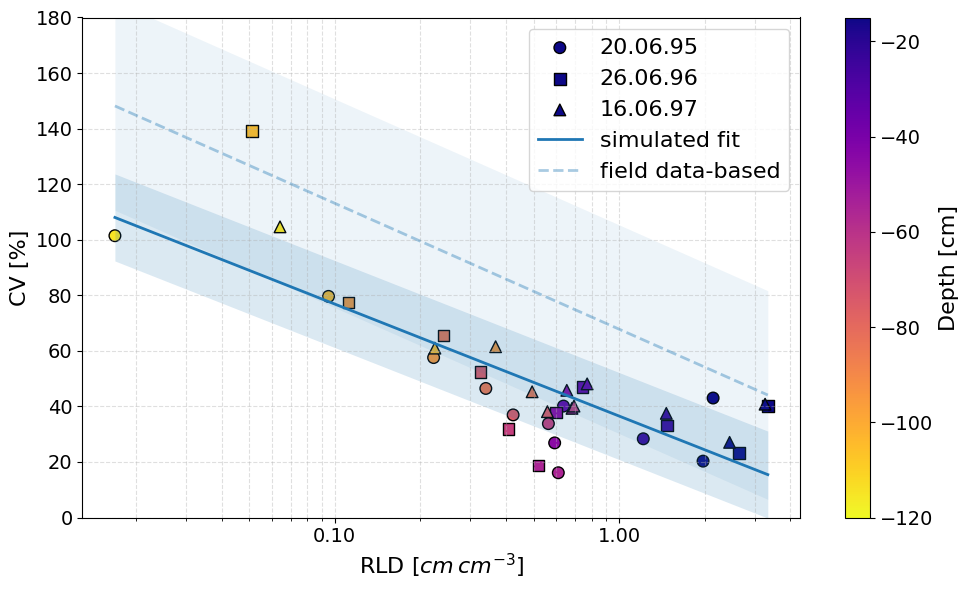

In [9]:
simulated_data = {
        "20.06.95": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1995_cores_2_layer_10.csv",
        "26.06.96": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1996_cores_2_layer_10.csv",
        "16.06.97": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1997_cores_2_layer_10.csv",
    }

simulated_fit = load_simulated_regression_fit(simulated_data=simulated_data, sd_multiplier=SD_BAND_MULTIPLIER, rld_min=0.007)
a_sim, b_sim = simulated_fit["a"], simulated_fit["b"]

markers = {
    "20.06.95": "o",   # circle
    "26.06.96": "s",   # square
    "16.06.97": "^",   # triangle
}

all_points = []

for label, file in simulated_data.items():

    # Load file
    df = pd.read_csv(file)

    df = df.sort_values('depth')
    depths = df["depth"].to_numpy()
    # Filter for system = soil_core
    df = df[df['system'] == 'soil_core'].copy()
    
    # Sort by depth if available to ensure alignment with manual_depths
    if 'depth' in df.columns:
        df = df.sort_values('depth')

    rld = df["simulated_mean"].values
    
    # Print warning if any RLD is 0 (will not show on log plot)
    zeros_mask = rld <= 0
    if np.any(zeros_mask):
        print(f"[{label}] Warning: Found 0.0 RLD at depths {depths[zeros_mask]}. These will not appear on log-scale plot.")

    # Avoid division by zero if RLD is 0
    with np.errstate(divide='ignore', invalid='ignore'):
        cv = df["simulated_std"].values / rld * 100
        cv[rld == 0] = 0  # or NaN

    all_points.append((label, depths, rld, cv))


APPLY_RLD_MIN_FILTER = True
RLD_MIN_FOR_FIT = 0.007  # chosen to drop only the tiny-RLD outlier (current data)

fig, ax = plt.subplots(figsize=(10, 6))

# color map
cmap = plt.cm.plasma_r
norm = plt.Normalize(-120, -15)

# plot points
for label, depths, rld, cv in all_points:
    plot_mask = np.ones_like(rld, dtype=bool)
    if APPLY_RLD_MIN_FILTER:
        plot_mask &= (rld >= RLD_MIN_FOR_FIT)
    ax.scatter(
        rld[plot_mask], cv[plot_mask],
        c=-depths[plot_mask],
        cmap=cmap,
        norm=norm,
        marker=markers[label],
        edgecolor="black",
        s=70,
        label=label
    )

# Flatten all arrays
all_labels = np.concatenate([np.repeat(r[0], len(r[1])) for r in all_points])
all_depths = np.concatenate([r[1] for r in all_points])
all_rld = np.concatenate([r[2] for r in all_points])
all_cv  = np.concatenate([r[3] for r in all_points])

# Base filter: only finite values and positive RLD
mask = (all_rld > 0) & (~np.isnan(all_cv)) & (~np.isinf(all_cv))

# Optional: filter out very small RLD values from the regression fit (to avoid huge CV from near-zero means)
mask_fit = mask.copy()
if APPLY_RLD_MIN_FILTER:
    mask_fit &= (all_rld >= RLD_MIN_FOR_FIT)
    excluded = mask & (all_rld < RLD_MIN_FOR_FIT)
    print(f"Excluding {excluded.sum()} point(s) with RLD < {RLD_MIN_FOR_FIT:g} from regression")
    if excluded.sum() > 0:
        for lab, dep, r, c in zip(all_labels[excluded], all_depths[excluded], all_rld[excluded], all_cv[excluded]):
            print(f"  excluded: {lab} depth={dep:g}cm  RLD={r:.8f}  CV={c:.2f}%")


x_range = combined_log10_x_range(field_fit, simulated_fit)
plot_log10_regression_with_sd_band(
    ax,
    simulated_fit,
    x_range=x_range,
    line_label="simulated fit",
    line_style="-",
    line_alpha=1.0,
    band_alpha=0.16,
)
plot_log10_regression_with_sd_band(
    ax,
    field_fit,
    x_range=x_range,
    line_label="field data-based",
    line_style="--",
    line_alpha=0.38,
    band_alpha=0.08,
)

print("a =", simulated_fit["a"])
print("b =", simulated_fit["b"])

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="x", style="plain")
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel(r"RLD [$cm\, cm^{-3}$]", fontsize=16)
ax.set_ylabel("CV [%]", fontsize=16)
ax.set_ylim(0, 180)

cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label("Depth [cm]", fontsize=16)
cbar.ax.tick_params(labelsize=14)

ax.legend(title="", frameon=True, fontsize=16)

ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 2 cores, 5 cm thick layers

[26.06.96] Warning: Found 0.0 RLD at depths [117.5]. These will not appear on log-scale plot.
Excluding 1 point(s) with RLD < 0.007 from regression
  excluded: 26.06.96 depth=112.5cm  RLD=0.00444272  CV=223.61%
a = -45.44126575397869
b = 37.594013722825935


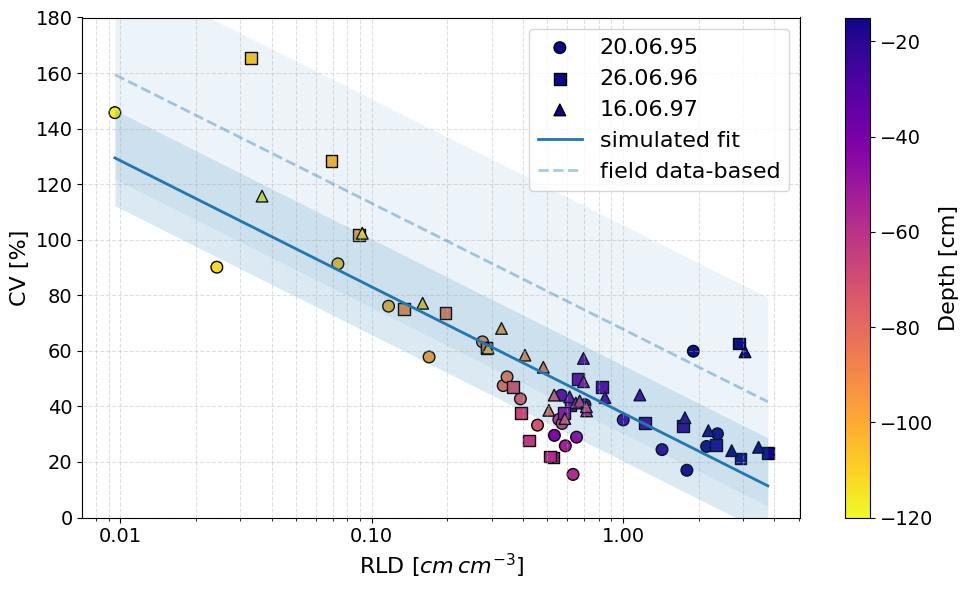

In [16]:
simulated_data = {
        "20.06.95": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1995_cores_2_layer_5.csv",
        "26.06.96": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1996_cores_2_layer_5.csv",
        "16.06.97": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1997_cores_2_layer_5.csv",
    }

simulated_fit = load_simulated_regression_fit(simulated_data=simulated_data, sd_multiplier=SD_BAND_MULTIPLIER, rld_min=0.007)
a_sim, b_sim = simulated_fit["a"], simulated_fit["b"]

markers = {
    "20.06.95": "o",   # circle
    "26.06.96": "s",   # square
    "16.06.97": "^",   # triangle
}

all_points = []

for label, file in simulated_data.items():

    # Load file
    df = pd.read_csv(file)

    df = df.sort_values('depth')
    depths = df["depth"].to_numpy()
    # Filter for system = soil_core
    df = df[df['system'] == 'soil_core'].copy()
    
    # Sort by depth if available to ensure alignment with manual_depths
    if 'depth' in df.columns:
        df = df.sort_values('depth')

    rld = df["simulated_mean"].values
    
    # Print warning if any RLD is 0 (will not show on log plot)
    zeros_mask = rld <= 0
    if np.any(zeros_mask):
        print(f"[{label}] Warning: Found 0.0 RLD at depths {depths[zeros_mask]}. These will not appear on log-scale plot.")

    # Avoid division by zero if RLD is 0
    with np.errstate(divide='ignore', invalid='ignore'):
        cv = df["simulated_std"].values / rld * 100
        cv[rld == 0] = 0  # or NaN

    all_points.append((label, depths, rld, cv))


APPLY_RLD_MIN_FILTER = True
RLD_MIN_FOR_FIT = 0.007  # chosen to drop only the tiny-RLD outlier (current data)

fig, ax = plt.subplots(figsize=(10, 6))

# color map
cmap = plt.cm.plasma_r
norm = plt.Normalize(-120, -15)

# plot points
for label, depths, rld, cv in all_points:
    plot_mask = np.ones_like(rld, dtype=bool)
    if APPLY_RLD_MIN_FILTER:
        plot_mask &= (rld >= RLD_MIN_FOR_FIT)
    ax.scatter(
        rld[plot_mask], cv[plot_mask],
        c=-depths[plot_mask],
        cmap=cmap,
        norm=norm,
        marker=markers[label],
        edgecolor="black",
        s=70,
        label=label
    )

# Flatten all arrays
all_labels = np.concatenate([np.repeat(r[0], len(r[1])) for r in all_points])
all_depths = np.concatenate([r[1] for r in all_points])
all_rld = np.concatenate([r[2] for r in all_points])
all_cv  = np.concatenate([r[3] for r in all_points])

# Base filter: only finite values and positive RLD
mask = (all_rld > 0) & (~np.isnan(all_cv)) & (~np.isinf(all_cv))

# Optional: filter out very small RLD values from the regression fit (to avoid huge CV from near-zero means)
mask_fit = mask.copy()
if APPLY_RLD_MIN_FILTER:
    mask_fit &= (all_rld >= RLD_MIN_FOR_FIT)
    excluded = mask & (all_rld < RLD_MIN_FOR_FIT)
    print(f"Excluding {excluded.sum()} point(s) with RLD < {RLD_MIN_FOR_FIT:g} from regression")
    if excluded.sum() > 0:
        for lab, dep, r, c in zip(all_labels[excluded], all_depths[excluded], all_rld[excluded], all_cv[excluded]):
            print(f"  excluded: {lab} depth={dep:g}cm  RLD={r:.8f}  CV={c:.2f}%")


x_range = combined_log10_x_range(field_fit, simulated_fit)
plot_log10_regression_with_sd_band(
    ax,
    simulated_fit,
    x_range=x_range,
    line_label="simulated fit",
    line_style="-",
    line_alpha=1.0,
    band_alpha=0.16
)
plot_log10_regression_with_sd_band(
    ax,
    field_fit,
    x_range=x_range,
    line_label="field data-based",
    line_style="--",
    line_alpha=0.38,
    band_alpha=0.08
)

print("a =", simulated_fit["a"])
print("b =", simulated_fit["b"])

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="x", style="plain")
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel(r"RLD [$cm\, cm^{-3}$]", fontsize=16)
ax.set_ylabel("CV [%]", fontsize=16)
ax.set_ylim(0, 180)

cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label("Depth [cm]", fontsize=16)
cbar.ax.tick_params(labelsize=14)

ax.legend(title="", frameon=True, fontsize=16)

ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 3 cores, 15 cm thick layers

Excluding 0 point(s) with RLD < 0.007 from regression
a = -54.71941554817126
b = 32.894404189501394


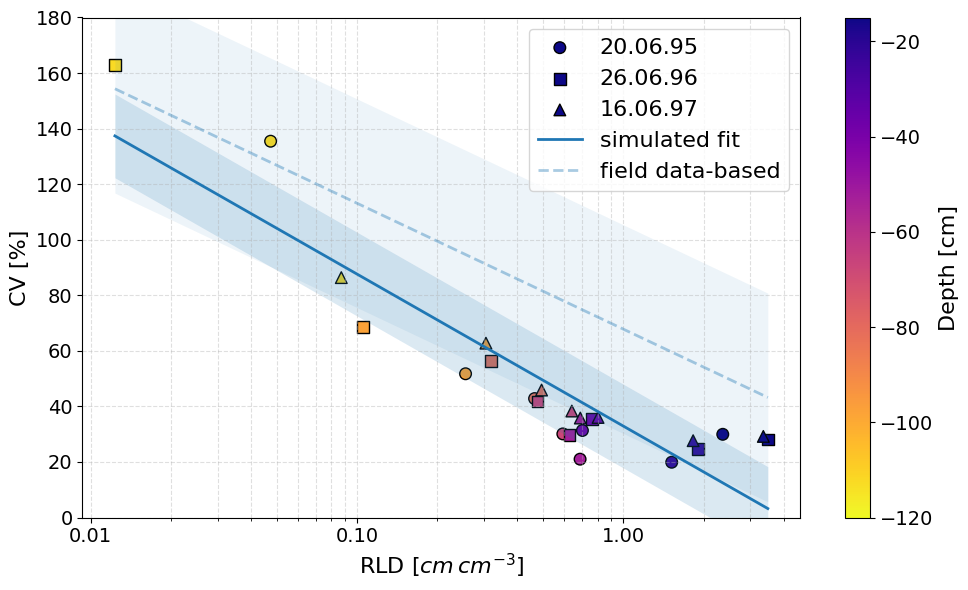

In [17]:
simulated_data = {
        "20.06.95": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1995_cores_3_layer_15.csv",
        "26.06.96": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1996_cores_3_layer_15.csv",
        "16.06.97": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1997_cores_3_layer_15.csv",
    }

simulated_fit = load_simulated_regression_fit(simulated_data=simulated_data, sd_multiplier=SD_BAND_MULTIPLIER, rld_min=0.007)
a_sim, b_sim = simulated_fit["a"], simulated_fit["b"]

markers = {
    "20.06.95": "o",   # circle
    "26.06.96": "s",   # square
    "16.06.97": "^",   # triangle
}

all_points = []

for label, file in simulated_data.items():

    # Load file
    df = pd.read_csv(file)

    df = df.sort_values('depth')
    depths = df["depth"].to_numpy()
    # Filter for system = soil_core
    df = df[df['system'] == 'soil_core'].copy()
    
    # Sort by depth if available to ensure alignment with manual_depths
    if 'depth' in df.columns:
        df = df.sort_values('depth')

    rld = df["simulated_mean"].values
    
    # Print warning if any RLD is 0 (will not show on log plot)
    zeros_mask = rld <= 0
    if np.any(zeros_mask):
        print(f"[{label}] Warning: Found 0.0 RLD at depths {depths[zeros_mask]}. These will not appear on log-scale plot.")

    # Avoid division by zero if RLD is 0
    with np.errstate(divide='ignore', invalid='ignore'):
        cv = df["simulated_std"].values / rld * 100
        cv[rld == 0] = 0  # or NaN

    all_points.append((label, depths, rld, cv))


APPLY_RLD_MIN_FILTER = True
RLD_MIN_FOR_FIT = 0.007  # chosen to drop only the tiny-RLD outlier (current data)

fig, ax = plt.subplots(figsize=(10, 6))

# color map
cmap = plt.cm.plasma_r
norm = plt.Normalize(-120, -15)

# plot points
for label, depths, rld, cv in all_points:
    plot_mask = np.ones_like(rld, dtype=bool)
    if APPLY_RLD_MIN_FILTER:
        plot_mask &= (rld >= RLD_MIN_FOR_FIT)
    ax.scatter(
        rld[plot_mask], cv[plot_mask],
        c=-depths[plot_mask],
        cmap=cmap,
        norm=norm,
        marker=markers[label],
        edgecolor="black",
        s=70,
        label=label
    )

# Flatten all arrays
all_labels = np.concatenate([np.repeat(r[0], len(r[1])) for r in all_points])
all_depths = np.concatenate([r[1] for r in all_points])
all_rld = np.concatenate([r[2] for r in all_points])
all_cv  = np.concatenate([r[3] for r in all_points])

# Base filter: only finite values and positive RLD
mask = (all_rld > 0) & (~np.isnan(all_cv)) & (~np.isinf(all_cv))

# Optional: filter out very small RLD values from the regression fit (to avoid huge CV from near-zero means)
mask_fit = mask.copy()
if APPLY_RLD_MIN_FILTER:
    mask_fit &= (all_rld >= RLD_MIN_FOR_FIT)
    excluded = mask & (all_rld < RLD_MIN_FOR_FIT)
    print(f"Excluding {excluded.sum()} point(s) with RLD < {RLD_MIN_FOR_FIT:g} from regression")
    if excluded.sum() > 0:
        for lab, dep, r, c in zip(all_labels[excluded], all_depths[excluded], all_rld[excluded], all_cv[excluded]):
            print(f"  excluded: {lab} depth={dep:g}cm  RLD={r:.8f}  CV={c:.2f}%")


x_range = combined_log10_x_range(field_fit, simulated_fit)
plot_log10_regression_with_sd_band(
    ax,
    simulated_fit,
    x_range=x_range,
    line_label="simulated fit",
    line_style="-",
    line_alpha=1.0,
    band_alpha=0.16
)
plot_log10_regression_with_sd_band(
    ax,
    field_fit,
    x_range=x_range,
    line_label="field data-based",
    line_style="--",
    line_alpha=0.38,
    band_alpha=0.08
)

print("a =", simulated_fit["a"])
print("b =", simulated_fit["b"])

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="x", style="plain")
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel(r"RLD [$cm\, cm^{-3}$]", fontsize=16)
ax.set_ylabel("CV [%]", fontsize=16)
ax.set_ylim(0, 180)

cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label("Depth [cm]", fontsize=16)
cbar.ax.tick_params(labelsize=14)

ax.legend(title="", frameon=True, fontsize=16)

ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 3 cores, 10 cm thick layers

Excluding 1 point(s) with RLD < 0.007 from regression
  excluded: 26.06.96 depth=115cm  RLD=0.00148091  CV=282.84%
a = -51.69315984279287
b = 34.2966376247831


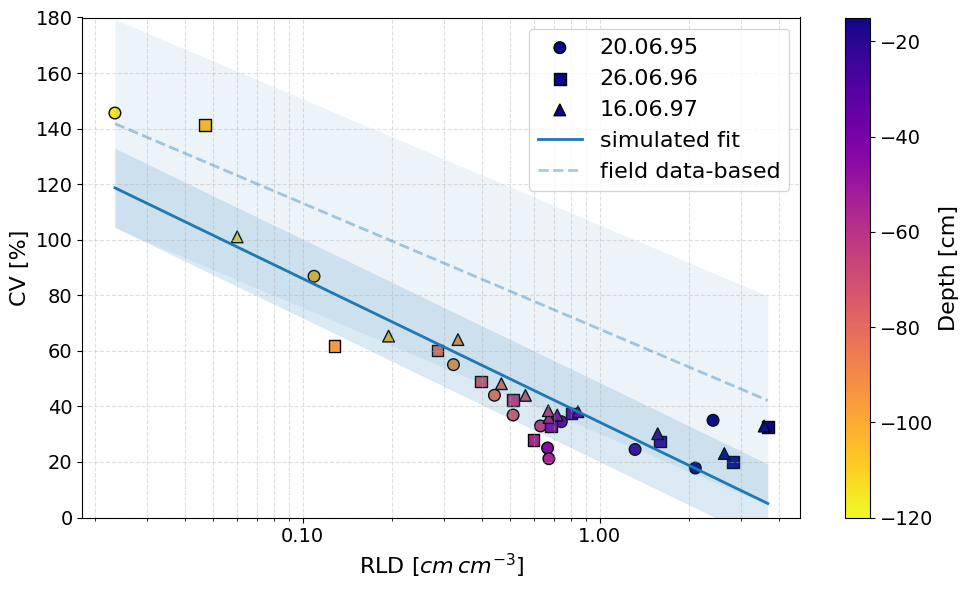

In [18]:
simulated_data = {
        "20.06.95": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1995_cores_3_layer_10.csv",
        "26.06.96": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1996_cores_3_layer_10.csv",
        "16.06.97": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1997_cores_3_layer_10.csv",
    }

simulated_fit = load_simulated_regression_fit(simulated_data=simulated_data, sd_multiplier=SD_BAND_MULTIPLIER, rld_min=0.007)
a_sim, b_sim = simulated_fit["a"], simulated_fit["b"]

markers = {
    "20.06.95": "o",   # circle
    "26.06.96": "s",   # square
    "16.06.97": "^",   # triangle
}

all_points = []

for label, file in simulated_data.items():

    # Load file
    df = pd.read_csv(file)

    df = df.sort_values('depth')
    depths = df["depth"].to_numpy()
    # Filter for system = soil_core
    df = df[df['system'] == 'soil_core'].copy()
    
    # Sort by depth if available to ensure alignment with manual_depths
    if 'depth' in df.columns:
        df = df.sort_values('depth')

    rld = df["simulated_mean"].values
    
    # Print warning if any RLD is 0 (will not show on log plot)
    zeros_mask = rld <= 0
    if np.any(zeros_mask):
        print(f"[{label}] Warning: Found 0.0 RLD at depths {depths[zeros_mask]}. These will not appear on log-scale plot.")

    # Avoid division by zero if RLD is 0
    with np.errstate(divide='ignore', invalid='ignore'):
        cv = df["simulated_std"].values / rld * 100
        cv[rld == 0] = 0  # or NaN

    all_points.append((label, depths, rld, cv))


APPLY_RLD_MIN_FILTER = True
RLD_MIN_FOR_FIT = 0.007  # chosen to drop only the tiny-RLD outlier (current data)

fig, ax = plt.subplots(figsize=(10, 6))

# color map
cmap = plt.cm.plasma_r
norm = plt.Normalize(-120, -15)

# plot points
for label, depths, rld, cv in all_points:
    plot_mask = np.ones_like(rld, dtype=bool)
    if APPLY_RLD_MIN_FILTER:
        plot_mask &= (rld >= RLD_MIN_FOR_FIT)
    ax.scatter(
        rld[plot_mask], cv[plot_mask],
        c=-depths[plot_mask],
        cmap=cmap,
        norm=norm,
        marker=markers[label],
        edgecolor="black",
        s=70,
        label=label
    )

# Flatten all arrays
all_labels = np.concatenate([np.repeat(r[0], len(r[1])) for r in all_points])
all_depths = np.concatenate([r[1] for r in all_points])
all_rld = np.concatenate([r[2] for r in all_points])
all_cv  = np.concatenate([r[3] for r in all_points])

# Base filter: only finite values and positive RLD
mask = (all_rld > 0) & (~np.isnan(all_cv)) & (~np.isinf(all_cv))

# Optional: filter out very small RLD values from the regression fit (to avoid huge CV from near-zero means)
mask_fit = mask.copy()
if APPLY_RLD_MIN_FILTER:
    mask_fit &= (all_rld >= RLD_MIN_FOR_FIT)
    excluded = mask & (all_rld < RLD_MIN_FOR_FIT)
    print(f"Excluding {excluded.sum()} point(s) with RLD < {RLD_MIN_FOR_FIT:g} from regression")
    if excluded.sum() > 0:
        for lab, dep, r, c in zip(all_labels[excluded], all_depths[excluded], all_rld[excluded], all_cv[excluded]):
            print(f"  excluded: {lab} depth={dep:g}cm  RLD={r:.8f}  CV={c:.2f}%")


x_range = combined_log10_x_range(field_fit, simulated_fit)
plot_log10_regression_with_sd_band(
    ax,
    simulated_fit,
    x_range=x_range,
    line_label="simulated fit",
    line_style="-",
    line_alpha=1.0,
    band_alpha=0.16
)
plot_log10_regression_with_sd_band(
    ax,
    field_fit,
    x_range=x_range,
    line_label="field data-based",
    line_style="--",
    line_alpha=0.38,
    band_alpha=0.08
)

print("a =", simulated_fit["a"])
print("b =", simulated_fit["b"])

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="x", style="plain")
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel(r"RLD [$cm\, cm^{-3}$]", fontsize=16)
ax.set_ylabel("CV [%]", fontsize=16)
ax.set_ylim(0, 180)

cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label("Depth [cm]", fontsize=16)
cbar.ax.tick_params(labelsize=14)

ax.legend(title="", frameon=True, fontsize=16)

ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 3 cores, 5 cm thick layers

[26.06.96] Warning: Found 0.0 RLD at depths [117.5]. These will not appear on log-scale plot.
Excluding 1 point(s) with RLD < 0.007 from regression
  excluded: 26.06.96 depth=112.5cm  RLD=0.00296181  CV=282.84%
a = -55.87497581834095
b = 35.95859702503014


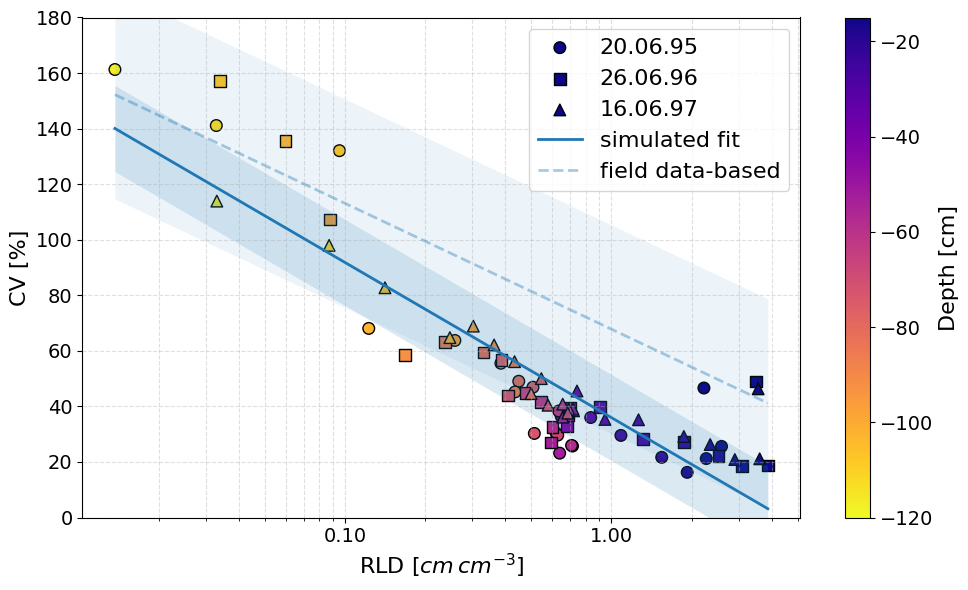

In [19]:
simulated_data = {
        "20.06.95": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1995_cores_3_layer_5.csv",
        "26.06.96": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1996_cores_3_layer_5.csv",
        "16.06.97": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1997_cores_3_layer_5.csv",
    }

simulated_fit = load_simulated_regression_fit(simulated_data=simulated_data, sd_multiplier=SD_BAND_MULTIPLIER, rld_min=0.007)
a_sim, b_sim = simulated_fit["a"], simulated_fit["b"]

markers = {
    "20.06.95": "o",   # circle
    "26.06.96": "s",   # square
    "16.06.97": "^",   # triangle
}

all_points = []

for label, file in simulated_data.items():

    # Load file
    df = pd.read_csv(file)

    df = df.sort_values('depth')
    depths = df["depth"].to_numpy()
    # Filter for system = soil_core
    df = df[df['system'] == 'soil_core'].copy()
    
    # Sort by depth if available to ensure alignment with manual_depths
    if 'depth' in df.columns:
        df = df.sort_values('depth')

    rld = df["simulated_mean"].values
    
    # Print warning if any RLD is 0 (will not show on log plot)
    zeros_mask = rld <= 0
    if np.any(zeros_mask):
        print(f"[{label}] Warning: Found 0.0 RLD at depths {depths[zeros_mask]}. These will not appear on log-scale plot.")

    # Avoid division by zero if RLD is 0
    with np.errstate(divide='ignore', invalid='ignore'):
        cv = df["simulated_std"].values / rld * 100
        cv[rld == 0] = 0  # or NaN

    all_points.append((label, depths, rld, cv))


APPLY_RLD_MIN_FILTER = True
RLD_MIN_FOR_FIT = 0.007  # chosen to drop only the tiny-RLD outlier (current data)

fig, ax = plt.subplots(figsize=(10, 6))

# color map
cmap = plt.cm.plasma_r
norm = plt.Normalize(-120, -15)

# plot points
for label, depths, rld, cv in all_points:
    plot_mask = np.ones_like(rld, dtype=bool)
    if APPLY_RLD_MIN_FILTER:
        plot_mask &= (rld >= RLD_MIN_FOR_FIT)
    ax.scatter(
        rld[plot_mask], cv[plot_mask],
        c=-depths[plot_mask],
        cmap=cmap,
        norm=norm,
        marker=markers[label],
        edgecolor="black",
        s=70,
        label=label
    )

# Flatten all arrays
all_labels = np.concatenate([np.repeat(r[0], len(r[1])) for r in all_points])
all_depths = np.concatenate([r[1] for r in all_points])
all_rld = np.concatenate([r[2] for r in all_points])
all_cv  = np.concatenate([r[3] for r in all_points])

# Base filter: only finite values and positive RLD
mask = (all_rld > 0) & (~np.isnan(all_cv)) & (~np.isinf(all_cv))

# Optional: filter out very small RLD values from the regression fit (to avoid huge CV from near-zero means)
mask_fit = mask.copy()
if APPLY_RLD_MIN_FILTER:
    mask_fit &= (all_rld >= RLD_MIN_FOR_FIT)
    excluded = mask & (all_rld < RLD_MIN_FOR_FIT)
    print(f"Excluding {excluded.sum()} point(s) with RLD < {RLD_MIN_FOR_FIT:g} from regression")
    if excluded.sum() > 0:
        for lab, dep, r, c in zip(all_labels[excluded], all_depths[excluded], all_rld[excluded], all_cv[excluded]):
            print(f"  excluded: {lab} depth={dep:g}cm  RLD={r:.8f}  CV={c:.2f}%")


x_range = combined_log10_x_range(field_fit, simulated_fit)
plot_log10_regression_with_sd_band(
    ax,
    simulated_fit,
    x_range=x_range,
    line_label="simulated fit",
    line_style="-",
    line_alpha=1.0,
    band_alpha=0.16
)
plot_log10_regression_with_sd_band(
    ax,
    field_fit,
    x_range=x_range,
    line_label="field data-based",
    line_style="--",
    line_alpha=0.38,
    band_alpha=0.08
)

print("a =", simulated_fit["a"])
print("b =", simulated_fit["b"])

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="x", style="plain")
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel(r"RLD [$cm\, cm^{-3}$]", fontsize=16)
ax.set_ylabel("CV [%]", fontsize=16)
ax.set_ylim(0, 180)

cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label("Depth [cm]", fontsize=16)
cbar.ax.tick_params(labelsize=14)

ax.legend(title="", frameon=True, fontsize=16)

ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 5 cores, 15 cm thick layers

Excluding 1 point(s) with RLD < 0.007 from regression
  excluded: 26.06.96 depth=112.5cm  RLD=0.00499460  CV=212.08%
a = -65.10681148295812
b = 37.8801976750791


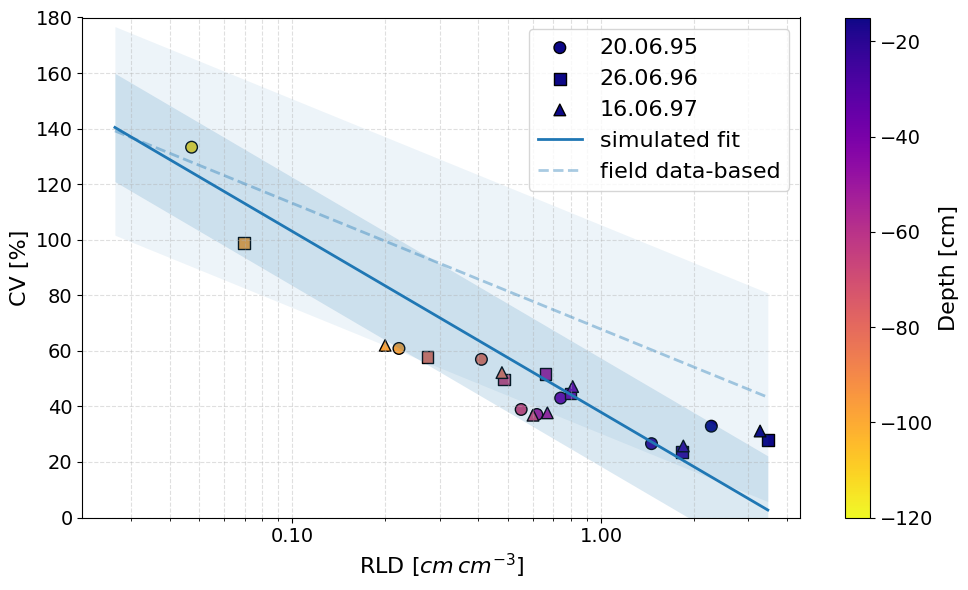

In [20]:
simulated_data = {
        "20.06.95": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1995_cores_5_layer_15.csv",
        "26.06.96": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1996_cores_5_layer_15.csv",
        "16.06.97": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1997_cores_5_layer_15.csv",
    }

simulated_fit = load_simulated_regression_fit(simulated_data=simulated_data, sd_multiplier=SD_BAND_MULTIPLIER, rld_min=0.007)
a_sim, b_sim = simulated_fit["a"], simulated_fit["b"]

markers = {
    "20.06.95": "o",   # circle
    "26.06.96": "s",   # square
    "16.06.97": "^",   # triangle
}

all_points = []

for label, file in simulated_data.items():

    # Load file
    df = pd.read_csv(file)

    df = df.sort_values('depth')
    depths = df["depth"].to_numpy()
    # Filter for system = soil_core
    df = df[df['system'] == 'soil_core'].copy()
    
    # Sort by depth if available to ensure alignment with manual_depths
    if 'depth' in df.columns:
        df = df.sort_values('depth')

    rld = df["simulated_mean"].values
    
    # Print warning if any RLD is 0 (will not show on log plot)
    zeros_mask = rld <= 0
    if np.any(zeros_mask):
        print(f"[{label}] Warning: Found 0.0 RLD at depths {depths[zeros_mask]}. These will not appear on log-scale plot.")

    # Avoid division by zero if RLD is 0
    with np.errstate(divide='ignore', invalid='ignore'):
        cv = df["simulated_std"].values / rld * 100
        cv[rld == 0] = 0  # or NaN

    all_points.append((label, depths, rld, cv))


APPLY_RLD_MIN_FILTER = True
RLD_MIN_FOR_FIT = 0.007  # chosen to drop only the tiny-RLD outlier (current data)

fig, ax = plt.subplots(figsize=(10, 6))

# color map
cmap = plt.cm.plasma_r
norm = plt.Normalize(-120, -15)

# plot points
for label, depths, rld, cv in all_points:
    plot_mask = np.ones_like(rld, dtype=bool)
    if APPLY_RLD_MIN_FILTER:
        plot_mask &= (rld >= RLD_MIN_FOR_FIT)
    ax.scatter(
        rld[plot_mask], cv[plot_mask],
        c=-depths[plot_mask],
        cmap=cmap,
        norm=norm,
        marker=markers[label],
        edgecolor="black",
        s=70,
        label=label
    )

# Flatten all arrays
all_labels = np.concatenate([np.repeat(r[0], len(r[1])) for r in all_points])
all_depths = np.concatenate([r[1] for r in all_points])
all_rld = np.concatenate([r[2] for r in all_points])
all_cv  = np.concatenate([r[3] for r in all_points])

# Base filter: only finite values and positive RLD
mask = (all_rld > 0) & (~np.isnan(all_cv)) & (~np.isinf(all_cv))

# Optional: filter out very small RLD values from the regression fit (to avoid huge CV from near-zero means)
mask_fit = mask.copy()
if APPLY_RLD_MIN_FILTER:
    mask_fit &= (all_rld >= RLD_MIN_FOR_FIT)
    excluded = mask & (all_rld < RLD_MIN_FOR_FIT)
    print(f"Excluding {excluded.sum()} point(s) with RLD < {RLD_MIN_FOR_FIT:g} from regression")
    if excluded.sum() > 0:
        for lab, dep, r, c in zip(all_labels[excluded], all_depths[excluded], all_rld[excluded], all_cv[excluded]):
            print(f"  excluded: {lab} depth={dep:g}cm  RLD={r:.8f}  CV={c:.2f}%")


x_range = combined_log10_x_range(field_fit, simulated_fit)
plot_log10_regression_with_sd_band(
    ax,
    simulated_fit,
    x_range=x_range,
    line_label="simulated fit",
    line_style="-",
    line_alpha=1.0,
    band_alpha=0.16
)
plot_log10_regression_with_sd_band(
    ax,
    field_fit,
    x_range=x_range,
    line_label="field data-based",
    line_style="--",
    line_alpha=0.38,
    band_alpha=0.08
)

print("a =", simulated_fit["a"])
print("b =", simulated_fit["b"])

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="x", style="plain")
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel(r"RLD [$cm\, cm^{-3}$]", fontsize=16)
ax.set_ylabel("CV [%]", fontsize=16)
ax.set_ylim(0, 180)

cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label("Depth [cm]", fontsize=16)
cbar.ax.tick_params(labelsize=14)

ax.legend(title="", frameon=True, fontsize=16)

ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 5 cores, 10 cm thick layers

Excluding 1 point(s) with RLD < 0.007 from regression
  excluded: 26.06.96 depth=115cm  RLD=0.00092320  CV=374.17%
a = -76.87366991260393
b = 37.70199112635978


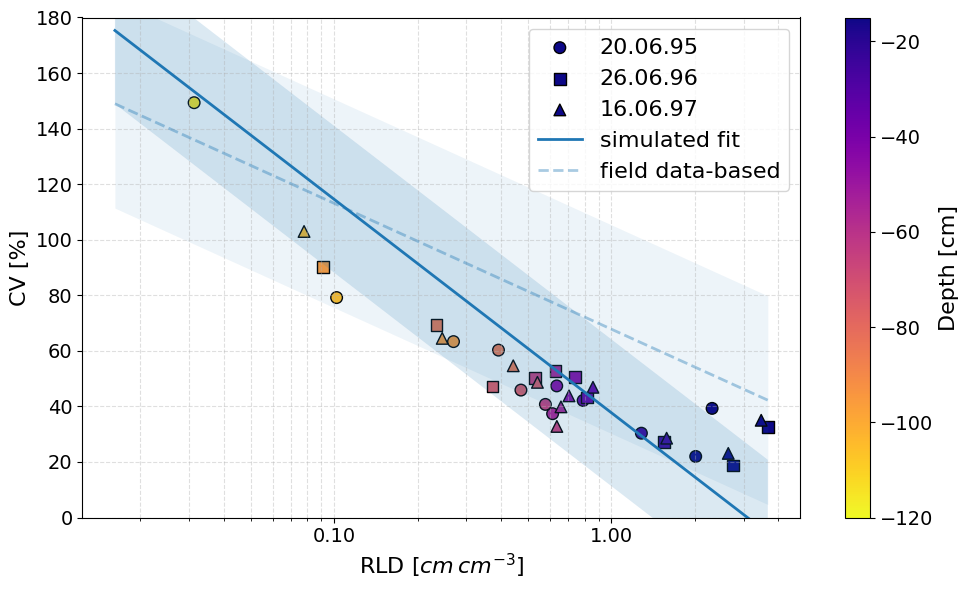

In [21]:
simulated_data = {
        "20.06.95": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1995_cores_5_layer_10.csv",
        "26.06.96": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1996_cores_5_layer_10.csv",
        "16.06.97": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1997_cores_5_layer_10.csv",
    }

simulated_fit = load_simulated_regression_fit(simulated_data=simulated_data, sd_multiplier=SD_BAND_MULTIPLIER, rld_min=0.007)
a_sim, b_sim = simulated_fit["a"], simulated_fit["b"]

markers = {
    "20.06.95": "o",   # circle
    "26.06.96": "s",   # square
    "16.06.97": "^",   # triangle
}

all_points = []

for label, file in simulated_data.items():

    # Load file
    df = pd.read_csv(file)

    df = df.sort_values('depth')
    depths = df["depth"].to_numpy()
    # Filter for system = soil_core
    df = df[df['system'] == 'soil_core'].copy()
    
    # Sort by depth if available to ensure alignment with manual_depths
    if 'depth' in df.columns:
        df = df.sort_values('depth')

    rld = df["simulated_mean"].values
    
    # Print warning if any RLD is 0 (will not show on log plot)
    zeros_mask = rld <= 0
    if np.any(zeros_mask):
        print(f"[{label}] Warning: Found 0.0 RLD at depths {depths[zeros_mask]}. These will not appear on log-scale plot.")

    # Avoid division by zero if RLD is 0
    with np.errstate(divide='ignore', invalid='ignore'):
        cv = df["simulated_std"].values / rld * 100
        cv[rld == 0] = 0  # or NaN

    all_points.append((label, depths, rld, cv))


APPLY_RLD_MIN_FILTER = True
RLD_MIN_FOR_FIT = 0.007  # chosen to drop only the tiny-RLD outlier (current data)

fig, ax = plt.subplots(figsize=(10, 6))

# color map
cmap = plt.cm.plasma_r
norm = plt.Normalize(-120, -15)

# plot points
for label, depths, rld, cv in all_points:
    plot_mask = np.ones_like(rld, dtype=bool)
    if APPLY_RLD_MIN_FILTER:
        plot_mask &= (rld >= RLD_MIN_FOR_FIT)
    ax.scatter(
        rld[plot_mask], cv[plot_mask],
        c=-depths[plot_mask],
        cmap=cmap,
        norm=norm,
        marker=markers[label],
        edgecolor="black",
        s=70,
        label=label
    )

# Flatten all arrays
all_labels = np.concatenate([np.repeat(r[0], len(r[1])) for r in all_points])
all_depths = np.concatenate([r[1] for r in all_points])
all_rld = np.concatenate([r[2] for r in all_points])
all_cv  = np.concatenate([r[3] for r in all_points])

# Base filter: only finite values and positive RLD
mask = (all_rld > 0) & (~np.isnan(all_cv)) & (~np.isinf(all_cv))

# Optional: filter out very small RLD values from the regression fit (to avoid huge CV from near-zero means)
mask_fit = mask.copy()
if APPLY_RLD_MIN_FILTER:
    mask_fit &= (all_rld >= RLD_MIN_FOR_FIT)
    excluded = mask & (all_rld < RLD_MIN_FOR_FIT)
    print(f"Excluding {excluded.sum()} point(s) with RLD < {RLD_MIN_FOR_FIT:g} from regression")
    if excluded.sum() > 0:
        for lab, dep, r, c in zip(all_labels[excluded], all_depths[excluded], all_rld[excluded], all_cv[excluded]):
            print(f"  excluded: {lab} depth={dep:g}cm  RLD={r:.8f}  CV={c:.2f}%")


x_range = combined_log10_x_range(field_fit, simulated_fit)
plot_log10_regression_with_sd_band(
    ax,
    simulated_fit,
    x_range=x_range,
    line_label="simulated fit",
    line_style="-",
    line_alpha=1.0,
    band_alpha=0.16
)
plot_log10_regression_with_sd_band(
    ax,
    field_fit,
    x_range=x_range,
    line_label="field data-based",
    line_style="--",
    line_alpha=0.38,
    band_alpha=0.08
)

print("a =", simulated_fit["a"])
print("b =", simulated_fit["b"])

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="x", style="plain")
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel(r"RLD [$cm\, cm^{-3}$]", fontsize=16)
ax.set_ylabel("CV [%]", fontsize=16)
ax.set_ylim(0, 180)

cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label("Depth [cm]", fontsize=16)
cbar.ax.tick_params(labelsize=14)

ax.legend(title="", frameon=True, fontsize=16)

ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 5 cores, 5 cm thick layers

[26.06.96] Warning: Found 0.0 RLD at depths [117.5]. These will not appear on log-scale plot.
Excluding 1 point(s) with RLD < 0.007 from regression
  excluded: 26.06.96 depth=112.5cm  RLD=0.00184640  CV=374.17%
a = -86.31866607126693
b = 38.8306864861648


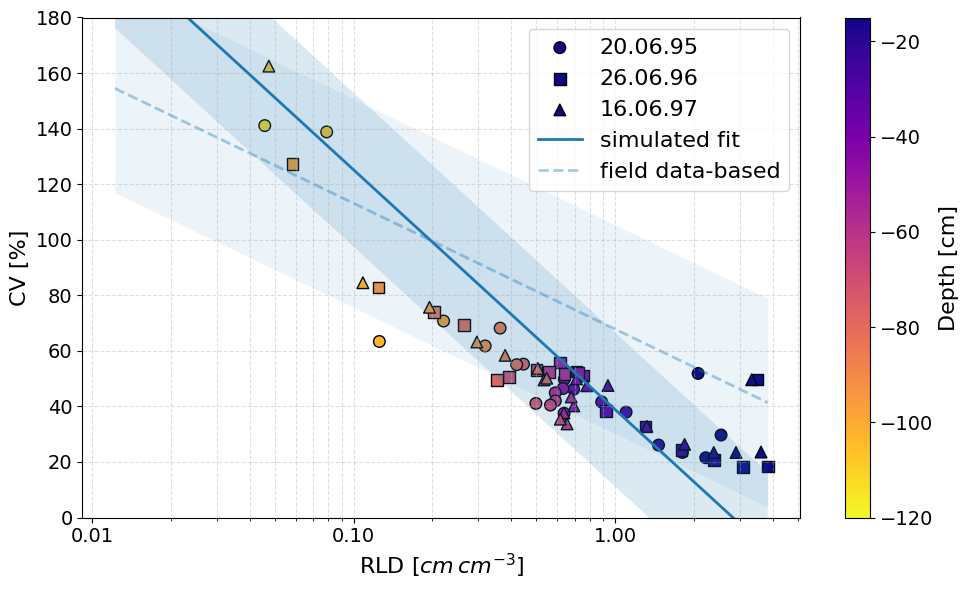

In [22]:
simulated_data = {
        "20.06.95": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1995_cores_5_layer_5.csv",
        "26.06.96": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1996_cores_5_layer_5.csv",
        "16.06.97": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1997_cores_5_layer_5.csv",
    }

simulated_fit = load_simulated_regression_fit(simulated_data=simulated_data, sd_multiplier=SD_BAND_MULTIPLIER, rld_min=0.007)
a_sim, b_sim = simulated_fit["a"], simulated_fit["b"]

markers = {
    "20.06.95": "o",   # circle
    "26.06.96": "s",   # square
    "16.06.97": "^",   # triangle
}

all_points = []

for label, file in simulated_data.items():

    # Load file
    df = pd.read_csv(file)

    df = df.sort_values('depth')
    depths = df["depth"].to_numpy()
    # Filter for system = soil_core
    df = df[df['system'] == 'soil_core'].copy()
    
    # Sort by depth if available to ensure alignment with manual_depths
    if 'depth' in df.columns:
        df = df.sort_values('depth')

    rld = df["simulated_mean"].values
    
    # Print warning if any RLD is 0 (will not show on log plot)
    zeros_mask = rld <= 0
    if np.any(zeros_mask):
        print(f"[{label}] Warning: Found 0.0 RLD at depths {depths[zeros_mask]}. These will not appear on log-scale plot.")

    # Avoid division by zero if RLD is 0
    with np.errstate(divide='ignore', invalid='ignore'):
        cv = df["simulated_std"].values / rld * 100
        cv[rld == 0] = 0  # or NaN

    all_points.append((label, depths, rld, cv))


APPLY_RLD_MIN_FILTER = True
RLD_MIN_FOR_FIT = 0.007  # chosen to drop only the tiny-RLD outlier (current data)

fig, ax = plt.subplots(figsize=(10, 6))

# color map
cmap = plt.cm.plasma_r
norm = plt.Normalize(-120, -15)

# plot points
for label, depths, rld, cv in all_points:
    plot_mask = np.ones_like(rld, dtype=bool)
    if APPLY_RLD_MIN_FILTER:
        plot_mask &= (rld >= RLD_MIN_FOR_FIT)
    ax.scatter(
        rld[plot_mask], cv[plot_mask],
        c=-depths[plot_mask],
        cmap=cmap,
        norm=norm,
        marker=markers[label],
        edgecolor="black",
        s=70,
        label=label
    )

# Flatten all arrays
all_labels = np.concatenate([np.repeat(r[0], len(r[1])) for r in all_points])
all_depths = np.concatenate([r[1] for r in all_points])
all_rld = np.concatenate([r[2] for r in all_points])
all_cv  = np.concatenate([r[3] for r in all_points])

# Base filter: only finite values and positive RLD
mask = (all_rld > 0) & (~np.isnan(all_cv)) & (~np.isinf(all_cv))

# Optional: filter out very small RLD values from the regression fit (to avoid huge CV from near-zero means)
mask_fit = mask.copy()
if APPLY_RLD_MIN_FILTER:
    mask_fit &= (all_rld >= RLD_MIN_FOR_FIT)
    excluded = mask & (all_rld < RLD_MIN_FOR_FIT)
    print(f"Excluding {excluded.sum()} point(s) with RLD < {RLD_MIN_FOR_FIT:g} from regression")
    if excluded.sum() > 0:
        for lab, dep, r, c in zip(all_labels[excluded], all_depths[excluded], all_rld[excluded], all_cv[excluded]):
            print(f"  excluded: {lab} depth={dep:g}cm  RLD={r:.8f}  CV={c:.2f}%")


x_range = combined_log10_x_range(field_fit, simulated_fit)
plot_log10_regression_with_sd_band(
    ax,
    simulated_fit,
    x_range=x_range,
    line_label="simulated fit",
    line_style="-",
    line_alpha=1.0,
    band_alpha=0.16
)
plot_log10_regression_with_sd_band(
    ax,
    field_fit,
    x_range=x_range,
    line_label="field data-based",
    line_style="--",
    line_alpha=0.38,
    band_alpha=0.08
)

print("a =", simulated_fit["a"])
print("b =", simulated_fit["b"])

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="x", style="plain")
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel(r"RLD [$cm\, cm^{-3}$]", fontsize=16)
ax.set_ylabel("CV [%]", fontsize=16)
ax.set_ylim(0, 180)

cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label("Depth [cm]", fontsize=16)
cbar.ax.tick_params(labelsize=14)

ax.legend(title="", frameon=True, fontsize=16)

ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 10 cores, 15 cm thick layers

Excluding 0 point(s) with RLD < 0.007 from regression
a = -84.90901159331607
b = 36.63593874101116


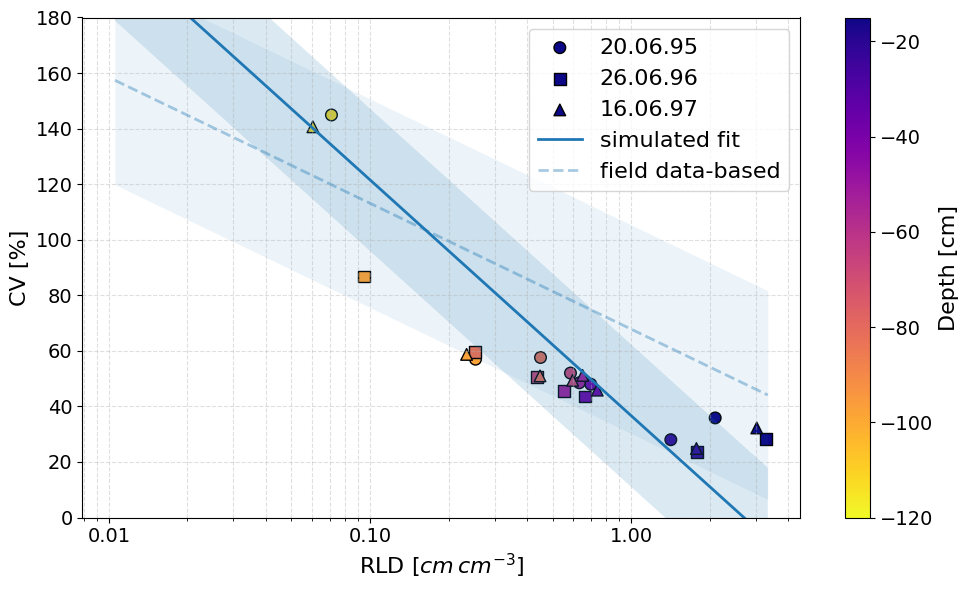

In [23]:
simulated_data = {
        "20.06.95": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1995_cores_10_layer_15.csv",
        "26.06.96": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1996_cores_10_layer_15.csv",
        "16.06.97": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1997_cores_10_layer_15.csv",
    }

simulated_fit = load_simulated_regression_fit(simulated_data=simulated_data, sd_multiplier=SD_BAND_MULTIPLIER, rld_min=0.007)
a_sim, b_sim = simulated_fit["a"], simulated_fit["b"]

markers = {
    "20.06.95": "o",   # circle
    "26.06.96": "s",   # square
    "16.06.97": "^",   # triangle
}

all_points = []

for label, file in simulated_data.items():

    # Load file
    df = pd.read_csv(file)

    df = df.sort_values('depth')
    depths = df["depth"].to_numpy()
    # Filter for system = soil_core
    df = df[df['system'] == 'soil_core'].copy()
    
    # Sort by depth if available to ensure alignment with manual_depths
    if 'depth' in df.columns:
        df = df.sort_values('depth')

    rld = df["simulated_mean"].values
    
    # Print warning if any RLD is 0 (will not show on log plot)
    zeros_mask = rld <= 0
    if np.any(zeros_mask):
        print(f"[{label}] Warning: Found 0.0 RLD at depths {depths[zeros_mask]}. These will not appear on log-scale plot.")

    # Avoid division by zero if RLD is 0
    with np.errstate(divide='ignore', invalid='ignore'):
        cv = df["simulated_std"].values / rld * 100
        cv[rld == 0] = 0  # or NaN

    all_points.append((label, depths, rld, cv))


APPLY_RLD_MIN_FILTER = True
RLD_MIN_FOR_FIT = 0.007  # chosen to drop only the tiny-RLD outlier (current data)

fig, ax = plt.subplots(figsize=(10, 6))

# color map
cmap = plt.cm.plasma_r
norm = plt.Normalize(-120, -15)

# plot points
for label, depths, rld, cv in all_points:
    plot_mask = np.ones_like(rld, dtype=bool)
    if APPLY_RLD_MIN_FILTER:
        plot_mask &= (rld >= RLD_MIN_FOR_FIT)
    ax.scatter(
        rld[plot_mask], cv[plot_mask],
        c=-depths[plot_mask],
        cmap=cmap,
        norm=norm,
        marker=markers[label],
        edgecolor="black",
        s=70,
        label=label
    )

# Flatten all arrays
all_labels = np.concatenate([np.repeat(r[0], len(r[1])) for r in all_points])
all_depths = np.concatenate([r[1] for r in all_points])
all_rld = np.concatenate([r[2] for r in all_points])
all_cv  = np.concatenate([r[3] for r in all_points])

# Base filter: only finite values and positive RLD
mask = (all_rld > 0) & (~np.isnan(all_cv)) & (~np.isinf(all_cv))

# Optional: filter out very small RLD values from the regression fit (to avoid huge CV from near-zero means)
mask_fit = mask.copy()
if APPLY_RLD_MIN_FILTER:
    mask_fit &= (all_rld >= RLD_MIN_FOR_FIT)
    excluded = mask & (all_rld < RLD_MIN_FOR_FIT)
    print(f"Excluding {excluded.sum()} point(s) with RLD < {RLD_MIN_FOR_FIT:g} from regression")
    if excluded.sum() > 0:
        for lab, dep, r, c in zip(all_labels[excluded], all_depths[excluded], all_rld[excluded], all_cv[excluded]):
            print(f"  excluded: {lab} depth={dep:g}cm  RLD={r:.8f}  CV={c:.2f}%")


x_range = combined_log10_x_range(field_fit, simulated_fit)
plot_log10_regression_with_sd_band(
    ax,
    simulated_fit,
    x_range=x_range,
    line_label="simulated fit",
    line_style="-",
    line_alpha=1.0,
    band_alpha=0.16
)
plot_log10_regression_with_sd_band(
    ax,
    field_fit,
    x_range=x_range,
    line_label="field data-based",
    line_style="--",
    line_alpha=0.38,
    band_alpha=0.08
)

print("a =", simulated_fit["a"])
print("b =", simulated_fit["b"])

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="x", style="plain")
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel(r"RLD [$cm\, cm^{-3}$]", fontsize=16)
ax.set_ylabel("CV [%]", fontsize=16)
ax.set_ylim(0, 180)

cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label("Depth [cm]", fontsize=16)
cbar.ax.tick_params(labelsize=14)

ax.legend(title="", frameon=True, fontsize=16)

ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 10 cores, 10 cm thick layers

Excluding 1 point(s) with RLD < 0.007 from regression
  excluded: 26.06.96 depth=115cm  RLD=0.00592939  CV=388.89%
a = -71.05209527495423
b = 39.71646318141418


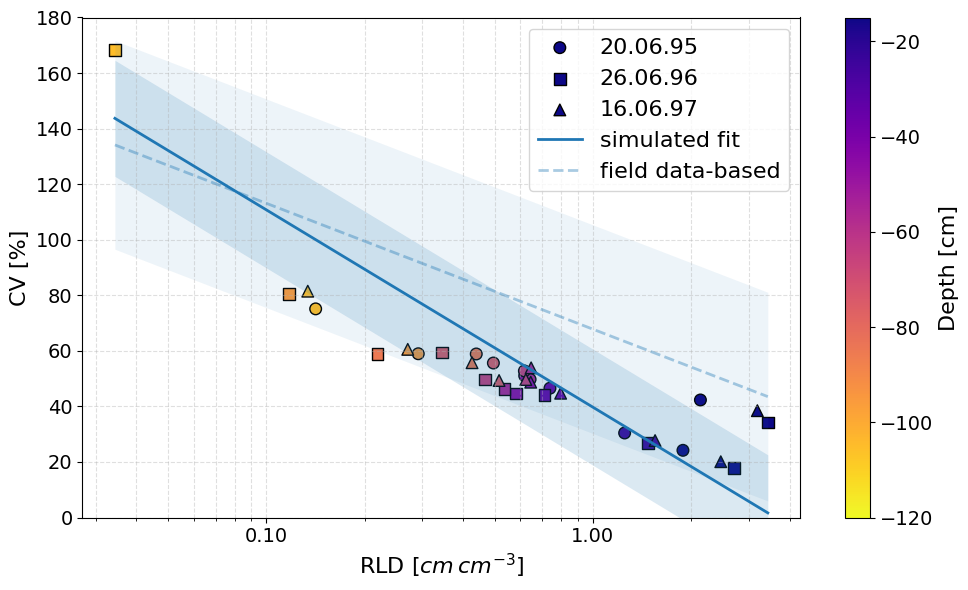

In [24]:
simulated_data = {
        "20.06.95": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1995_cores_10_layer_10.csv",
        "26.06.96": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1996_cores_10_layer_10.csv",
        "16.06.97": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1997_cores_10_layer_10.csv",
    }

simulated_fit = load_simulated_regression_fit(simulated_data=simulated_data, sd_multiplier=SD_BAND_MULTIPLIER, rld_min=0.007)
a_sim, b_sim = simulated_fit["a"], simulated_fit["b"]

markers = {
    "20.06.95": "o",   # circle
    "26.06.96": "s",   # square
    "16.06.97": "^",   # triangle
}

all_points = []

for label, file in simulated_data.items():

    # Load file
    df = pd.read_csv(file)

    df = df.sort_values('depth')
    depths = df["depth"].to_numpy()
    # Filter for system = soil_core
    df = df[df['system'] == 'soil_core'].copy()
    
    # Sort by depth if available to ensure alignment with manual_depths
    if 'depth' in df.columns:
        df = df.sort_values('depth')

    rld = df["simulated_mean"].values
    
    # Print warning if any RLD is 0 (will not show on log plot)
    zeros_mask = rld <= 0
    if np.any(zeros_mask):
        print(f"[{label}] Warning: Found 0.0 RLD at depths {depths[zeros_mask]}. These will not appear on log-scale plot.")

    # Avoid division by zero if RLD is 0
    with np.errstate(divide='ignore', invalid='ignore'):
        cv = df["simulated_std"].values / rld * 100
        cv[rld == 0] = 0  # or NaN

    all_points.append((label, depths, rld, cv))


APPLY_RLD_MIN_FILTER = True
RLD_MIN_FOR_FIT = 0.007  # chosen to drop only the tiny-RLD outlier (current data)

fig, ax = plt.subplots(figsize=(10, 6))

# color map
cmap = plt.cm.plasma_r
norm = plt.Normalize(-120, -15)

# plot points
for label, depths, rld, cv in all_points:
    plot_mask = np.ones_like(rld, dtype=bool)
    if APPLY_RLD_MIN_FILTER:
        plot_mask &= (rld >= RLD_MIN_FOR_FIT)
    ax.scatter(
        rld[plot_mask], cv[plot_mask],
        c=-depths[plot_mask],
        cmap=cmap,
        norm=norm,
        marker=markers[label],
        edgecolor="black",
        s=70,
        label=label
    )

# Flatten all arrays
all_labels = np.concatenate([np.repeat(r[0], len(r[1])) for r in all_points])
all_depths = np.concatenate([r[1] for r in all_points])
all_rld = np.concatenate([r[2] for r in all_points])
all_cv  = np.concatenate([r[3] for r in all_points])

# Base filter: only finite values and positive RLD
mask = (all_rld > 0) & (~np.isnan(all_cv)) & (~np.isinf(all_cv))

# Optional: filter out very small RLD values from the regression fit (to avoid huge CV from near-zero means)
mask_fit = mask.copy()
if APPLY_RLD_MIN_FILTER:
    mask_fit &= (all_rld >= RLD_MIN_FOR_FIT)
    excluded = mask & (all_rld < RLD_MIN_FOR_FIT)
    print(f"Excluding {excluded.sum()} point(s) with RLD < {RLD_MIN_FOR_FIT:g} from regression")
    if excluded.sum() > 0:
        for lab, dep, r, c in zip(all_labels[excluded], all_depths[excluded], all_rld[excluded], all_cv[excluded]):
            print(f"  excluded: {lab} depth={dep:g}cm  RLD={r:.8f}  CV={c:.2f}%")


x_range = combined_log10_x_range(field_fit, simulated_fit)
plot_log10_regression_with_sd_band(
    ax,
    simulated_fit,
    x_range=x_range,
    line_label="simulated fit",
    line_style="-",
    line_alpha=1.0,
    band_alpha=0.16
)
plot_log10_regression_with_sd_band(
    ax,
    field_fit,
    x_range=x_range,
    line_label="field data-based",
    line_style="--",
    line_alpha=0.38,
    band_alpha=0.08
)

print("a =", simulated_fit["a"])
print("b =", simulated_fit["b"])

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="x", style="plain")
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel(r"RLD [$cm\, cm^{-3}$]", fontsize=16)
ax.set_ylabel("CV [%]", fontsize=16)
ax.set_ylim(0, 180)

cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label("Depth [cm]", fontsize=16)
cbar.ax.tick_params(labelsize=14)

ax.legend(title="", frameon=True, fontsize=16)

ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 10 cores, 5 cm thick layers

Excluding 2 point(s) with RLD < 0.007 from regression
  excluded: 26.06.96 depth=112.5cm  RLD=0.00684985  CV=347.91%
  excluded: 26.06.96 depth=117.5cm  RLD=0.00500893  CV=453.21%
a = -83.36643322989559
b = 40.09796696216871


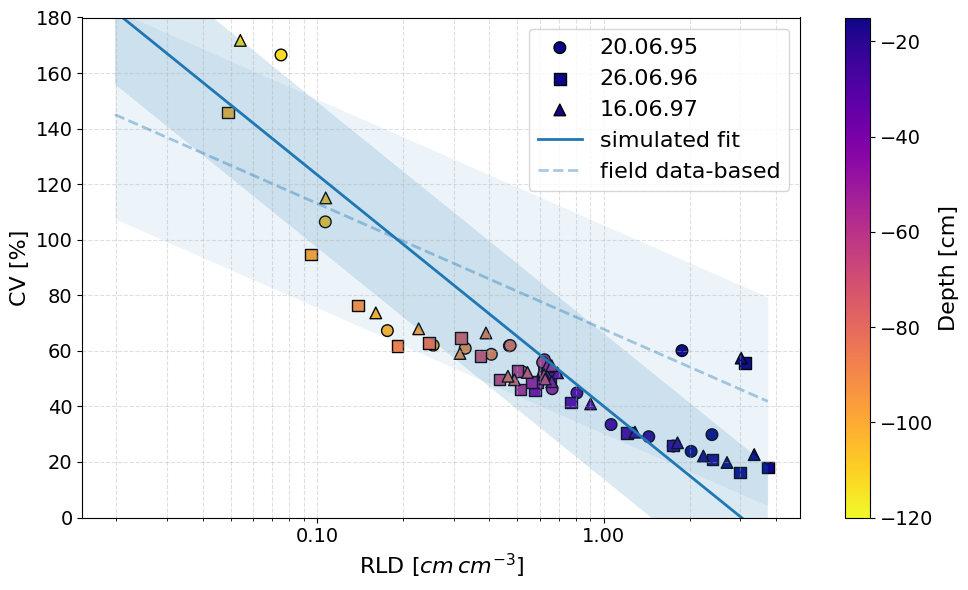

In [25]:
simulated_data = {
        "20.06.95": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1995_cores_10_layer_5.csv",
        "26.06.96": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1996_cores_10_layer_5.csv",
        "16.06.97": f"{BASE_DIR}/results/spatial_resolution_tests/full_data_csv_1997_cores_10_layer_5.csv",
    }

simulated_fit = load_simulated_regression_fit(simulated_data=simulated_data, sd_multiplier=SD_BAND_MULTIPLIER, rld_min=0.007)
a_sim, b_sim = simulated_fit["a"], simulated_fit["b"]

markers = {
    "20.06.95": "o",   # circle
    "26.06.96": "s",   # square
    "16.06.97": "^",   # triangle
}

all_points = []

for label, file in simulated_data.items():

    # Load file
    df = pd.read_csv(file)

    df = df.sort_values('depth')
    depths = df["depth"].to_numpy()
    # Filter for system = soil_core
    df = df[df['system'] == 'soil_core'].copy()
    
    # Sort by depth if available to ensure alignment with manual_depths
    if 'depth' in df.columns:
        df = df.sort_values('depth')

    rld = df["simulated_mean"].values
    
    # Print warning if any RLD is 0 (will not show on log plot)
    zeros_mask = rld <= 0
    if np.any(zeros_mask):
        print(f"[{label}] Warning: Found 0.0 RLD at depths {depths[zeros_mask]}. These will not appear on log-scale plot.")

    # Avoid division by zero if RLD is 0
    with np.errstate(divide='ignore', invalid='ignore'):
        cv = df["simulated_std"].values / rld * 100
        cv[rld == 0] = 0  # or NaN

    all_points.append((label, depths, rld, cv))


APPLY_RLD_MIN_FILTER = True
RLD_MIN_FOR_FIT = 0.007  # chosen to drop only the tiny-RLD outlier (current data)

fig, ax = plt.subplots(figsize=(10, 6))

# color map
cmap = plt.cm.plasma_r
norm = plt.Normalize(-120, -15)

# plot points
for label, depths, rld, cv in all_points:
    plot_mask = np.ones_like(rld, dtype=bool)
    if APPLY_RLD_MIN_FILTER:
        plot_mask &= (rld >= RLD_MIN_FOR_FIT)
    ax.scatter(
        rld[plot_mask], cv[plot_mask],
        c=-depths[plot_mask],
        cmap=cmap,
        norm=norm,
        marker=markers[label],
        edgecolor="black",
        s=70,
        label=label
    )

# Flatten all arrays
all_labels = np.concatenate([np.repeat(r[0], len(r[1])) for r in all_points])
all_depths = np.concatenate([r[1] for r in all_points])
all_rld = np.concatenate([r[2] for r in all_points])
all_cv  = np.concatenate([r[3] for r in all_points])

# Base filter: only finite values and positive RLD
mask = (all_rld > 0) & (~np.isnan(all_cv)) & (~np.isinf(all_cv))

# Optional: filter out very small RLD values from the regression fit (to avoid huge CV from near-zero means)
mask_fit = mask.copy()
if APPLY_RLD_MIN_FILTER:
    mask_fit &= (all_rld >= RLD_MIN_FOR_FIT)
    excluded = mask & (all_rld < RLD_MIN_FOR_FIT)
    print(f"Excluding {excluded.sum()} point(s) with RLD < {RLD_MIN_FOR_FIT:g} from regression")
    if excluded.sum() > 0:
        for lab, dep, r, c in zip(all_labels[excluded], all_depths[excluded], all_rld[excluded], all_cv[excluded]):
            print(f"  excluded: {lab} depth={dep:g}cm  RLD={r:.8f}  CV={c:.2f}%")


x_range = combined_log10_x_range(field_fit, simulated_fit)
plot_log10_regression_with_sd_band(
    ax,
    simulated_fit,
    x_range=x_range,
    line_label="simulated fit",
    line_style="-",
    line_alpha=1.0,
    band_alpha=0.16,
)
plot_log10_regression_with_sd_band(
    ax,
    field_fit,
    x_range=x_range,
    line_label="field data-based",
    line_style="--",
    line_alpha=0.38,
    band_alpha=0.08,
)

print("a =", simulated_fit["a"])
print("b =", simulated_fit["b"])

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="x", style="plain")
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel(r"RLD [$cm\, cm^{-3}$]", fontsize=16)
ax.set_ylabel("CV [%]", fontsize=16)
ax.set_ylim(0, 180)

cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label("Depth [cm]", fontsize=16)
cbar.ax.tick_params(labelsize=14)

ax.legend(title="", frameon=True, fontsize=16)

ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()